### 1. Import Libraries

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf

### 2. Load and Prepare Data

In [43]:
energy_hourly = pd.read_csv('../data/processed/energy_hourly.csv', index_col=0, parse_dates=True)
energy_hourly.head()

,Global_active_power
datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


### 3. Data Formatting for Prophet

In [44]:
prophet_df = energy_hourly.reset_index()
prophet_df.columns = ['ds', 'y']
prophet_df.head()

,ds,y
0,2006-12-16 17:00:00,4.222889
1,2006-12-16 18:00:00,3.632200
2,2006-12-16 19:00:00,3.400233
3,2006-12-16 20:00:00,3.268567
4,2006-12-16 21:00:00,3.056467


### 4. Train-Test Split

In [45]:
train_size = int(len(prophet_df) * 0.9)

train = prophet_df[:train_size]
test = prophet_df[train_size:]

### 5. Prophet Model Training

Prophet is used to model time series data with strong seasonality and trend components. It automatically handles daily and weekly seasonality.

In [46]:
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True
)

model.fit(train)

11:37:55 - cmdstanpy - INFO - Chain [1] start processing
11:38:00 - cmdstanpy - INFO - Chain [1] done processing


### 6. Forecast Generation

In [47]:
future = model.make_future_dataframe(periods=len(test), freq='h')
forecast = model.predict(future)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2006-12-16 17:00:00,1.396629,0.853799,2.782970,1.396629,1.396629,0.394440,0.394440,0.394440,-0.075799,...,0.170846,0.170846,0.170846,0.299392,0.299392,0.299392,0.0,0.0,0.0,1.791069
1,2006-12-16 18:00:00,1.396498,1.164430,3.069038,1.396498,1.396498,0.756484,0.756484,0.756484,0.278552,...,0.178289,0.178289,0.178289,0.299644,0.299644,0.299644,0.0,0.0,0.0,2.152982
2,2006-12-16 19:00:00,1.396368,1.632121,3.514251,1.396368,1.396368,1.170616,1.170616,1.170616,0.685619,...,0.185101,0.185101,0.185101,0.299896,0.299896,0.299896,0.0,0.0,0.0,2.566984
3,2006-12-16 20:00:00,1.396237,1.764673,3.682042,1.396237,1.396237,1.370203,1.370203,1.370203,0.878829,...,0.191224,0.191224,0.191224,0.300150,0.300150,0.300150,0.0,0.0,0.0,2.766440
4,2006-12-16 21:00:00,1.396107,1.633615,3.522512,1.396107,1.396107,1.217066,1.217066,1.217066,0.720056,...,0.196605,0.196605,0.196605,0.300405,0.300405,0.300405,0.0,0.0,0.0,2.613173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34584,2010-11-26 17:00:00,1.125882,0.466980,2.346963,1.072164,1.177333,0.255402,0.255402,0.255402,-0.075799,...,-0.045306,-0.045306,-0.045306,0.376507,0.376507,0.376507,0.0,0.0,0.0,1.381283
34585,2010-11-26 18:00:00,1.125886,0.790008,2.679030,1.072147,1.177359,0.616039,0.616039,0.616039,0.278552,...,-0.038883,-0.038883,-0.038883,0.376371,0.376371,0.376371,0.0,0.0,0.0,1.741925
34586,2010-11-26 19:00:00,1.125891,1.217769,3.074959,1.072129,1.177384,1.029779,1.029779,1.029779,0.685619,...,-0.032072,-0.032072,-0.032072,0.376231,0.376231,0.376231,0.0,0.0,0.0,2.155669
34587,2010-11-26 20:00:00,1.125895,1.406757,3.337741,1.072112,1.177410,1.230046,1.230046,1.230046,0.878829,...,-0.024872,-0.024872,-0.024872,0.376088,0.376088,0.376088,0.0,0.0,0.0,2.355941


- yhat → prediction
- yhat_lower → lower bound
- yhat_upper → upper bound

### 7. Forecast Visualization

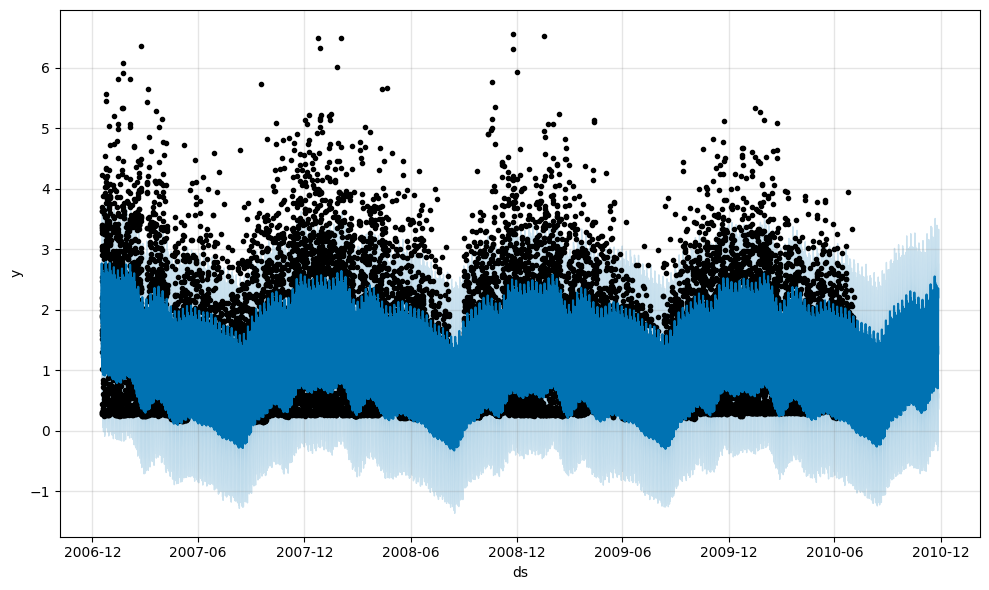

In [48]:
model.plot(forecast); 

- Black dots → actual
- Blue line → prediction
- Light blue → confidence interval

### 8. Components Analysis (Trend & Seasonality)

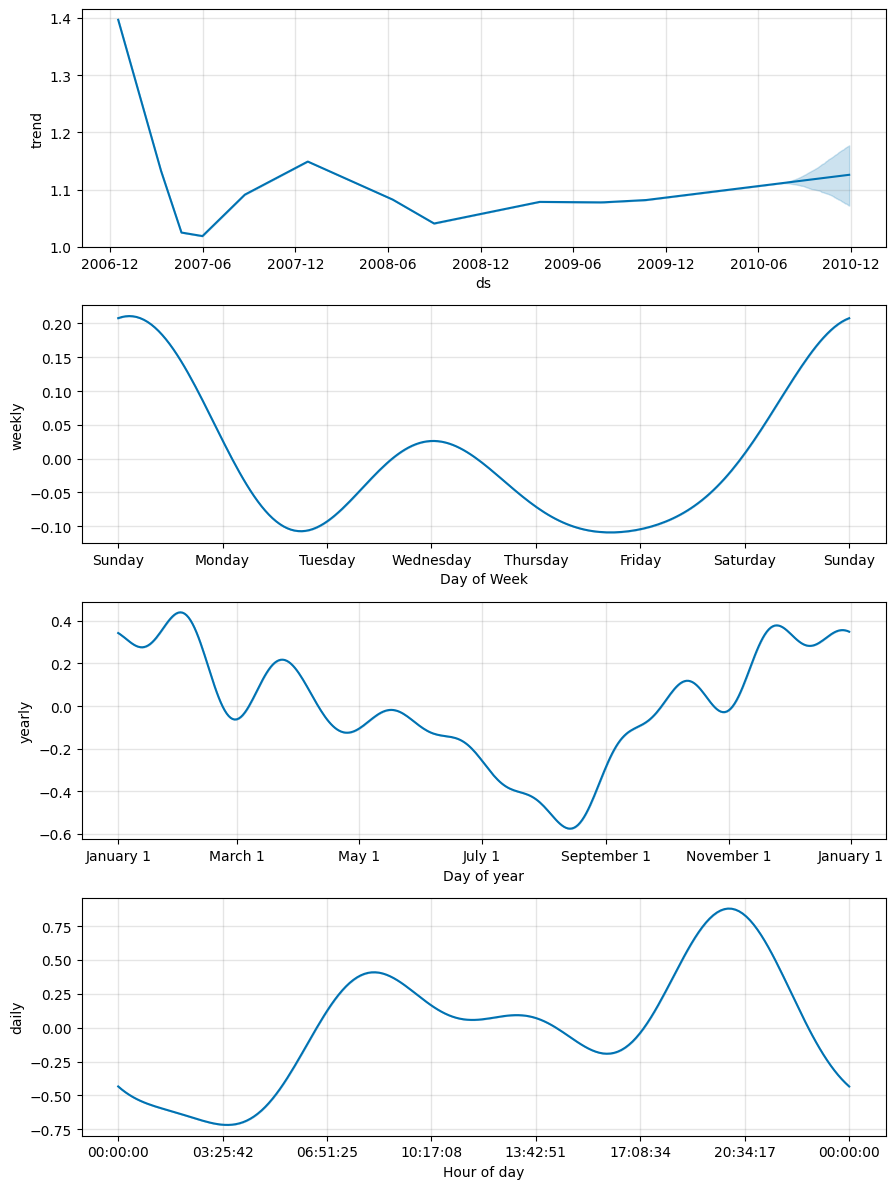

In [49]:
model.plot_components(forecast);

### 9. Model Evaluation Strategy

- The model is evaluated using a train-test split (90%-10%).  
- Performance is measured using MAE, RMSE, and MAPE.  
- A 24-hour forecast is also generated for short-term evaluation.

### 10. Model Evaluation (MAE, RMSE, MAPE)

In [50]:
forecast_test = forecast.iloc[-len(test):]

mae = mean_absolute_error(test['y'], forecast_test['yhat'])
rmse = np.sqrt(mean_squared_error(test['y'], forecast_test['yhat']))

print("MAE :", mae)
print("RMSE:", rmse)

def mape(y_true, y_pred):
    return (abs((y_true - y_pred) / y_true).mean()) * 100

mape_value = mape(test['y'], forecast_test['yhat'])
print("MAPE:", mape_value)

MAE : 0.49456349999508314
RMSE: 0.6399011808375922
MAPE: 82.3886291009464


The Prophet model was evaluated using MAE and RMSE.

- MAE measures average error magnitude
- RMSE penalizes larger errors more heavily
- MAPE provides a percentage-based error metric for better interpretability.

The results indicate that the model captures overall trends and seasonality effectively.

### Evaluation Interpretation

- MAE and RMSE indicate that the model provides reasonably accurate predictions.
- The MAPE value is relatively high due to the presence of small actual values in the dataset, which can inflate percentage-based errors.

This highlights a limitation of MAPE for datasets with values close to zero, and therefore MAE and RMSE are considered more reliable metrics in this context.

### 12. Prediction Interval Coverage

Prediction interval coverage measures how often the actual values fall within the predicted confidence interval.

A higher coverage indicates that the model provides reliable uncertainty estimates.

In [51]:
coverage = ((test['y'] >= forecast_test['yhat_lower']) & 
            (test['y'] <= forecast_test['yhat_upper'])).mean()

print("Prediction Interval Coverage:", coverage)

Prediction Interval Coverage: 0.8725065047701648


The model achieves approximately 87% coverage, indicating that most actual values fall within the predicted confidence intervals.

This suggests that the model provides reliable uncertainty estimates.

### 13. Final Forecast vs Actual

The following plot compares the model predictions with actual values on the test dataset.

This helps visually assess how well the model captures real-world patterns.

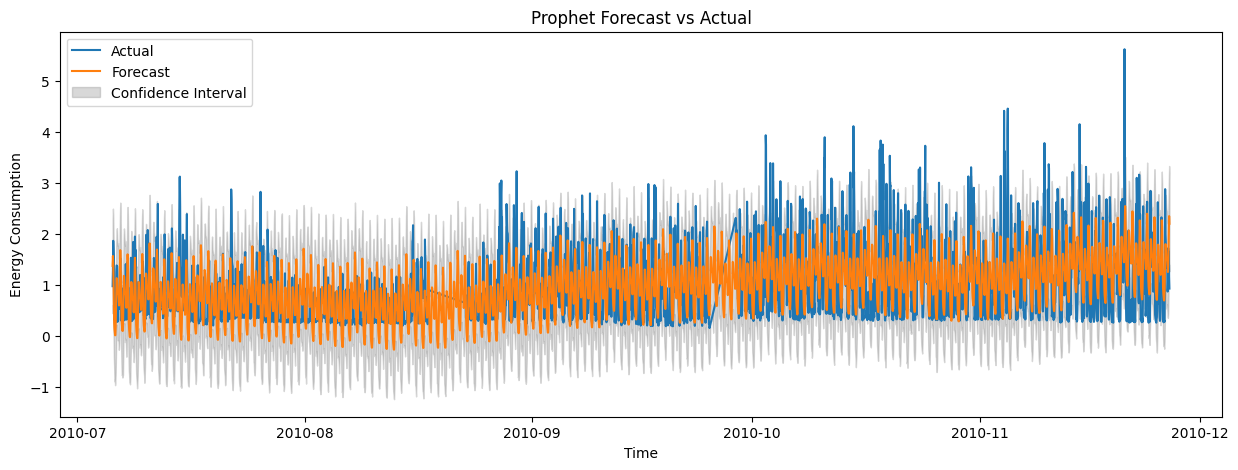

In [52]:
plt.figure(figsize=(15,5))

plt.plot(test['ds'], test['y'], label='Actual')
plt.plot(test['ds'], forecast_test['yhat'], label='Forecast')

plt.fill_between(
    test['ds'],
    forecast_test['yhat_lower'],
    forecast_test['yhat_upper'],
    color='gray',
    alpha=0.3,
    label='Confidence Interval'
)

plt.legend()
plt.title('Prophet Forecast vs Actual')
plt.xlabel('Time')
plt.ylabel('Energy Consumption')

plt.show()

### 14. Hyperparameter Tuning

- Hyperparameter tuning was performed to improve model performance by adjusting key parameters of the Prophet model.
- The parameter `changepoint_prior_scale` controls the flexibility of the trend. A higher value allows the model to adapt more quickly to changes in the data.

In [53]:
# Default model (already trained earlier)
mae_default = mae
rmse_default = rmse

# Tuned model
model_tuned = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    changepoint_prior_scale=0.5
)

model_tuned.fit(train)

future = model_tuned.make_future_dataframe(periods=len(test), freq='h')
forecast_tuned = model_tuned.predict(future)

forecast_test_tuned = forecast_tuned.iloc[-len(test):]

mae_tuned = mean_absolute_error(test['y'], forecast_test_tuned['yhat'])
rmse_tuned = np.sqrt(mean_squared_error(test['y'], forecast_test_tuned['yhat']))

print("Default MAE :", mae_default)
print("Tuned MAE   :", mae_tuned)

print("Default RMSE:", rmse_default)
print("Tuned RMSE  :", rmse_tuned)

11:38:06 - cmdstanpy - INFO - Chain [1] start processing
11:38:17 - cmdstanpy - INFO - Chain [1] done processing


Default MAE : 0.49456349999508314
Tuned MAE   : 0.4984589676144016
Default RMSE: 0.6399011808375922
Tuned RMSE  : 0.6417721621325545


### Hyperparameter Tuning Results

The tuned model was compared with the default configuration.

- Default MAE: 0.494  
- Tuned MAE: 0.498  
- Default RMSE: 0.639  
- Tuned RMSE: 0.641 

The tuned model showed slightly higher error compared to the default configuration.

This indicates that the default Prophet parameters are already well-suited for this dataset and provide better generalization.

This experiment highlights that hyperparameter tuning does not always guarantee improved performance and must be validated using proper evaluation metrics.

Prophet’s default configuration is often robust for datasets with clear seasonality, reducing the need for extensive tuning.

### 15. Residual Analysis

- Residuals appear randomly distributed around zero, indicating that the model has captured most of the underlying patterns in the data.
- No clear patterns or trends are observed, suggesting good model performance.

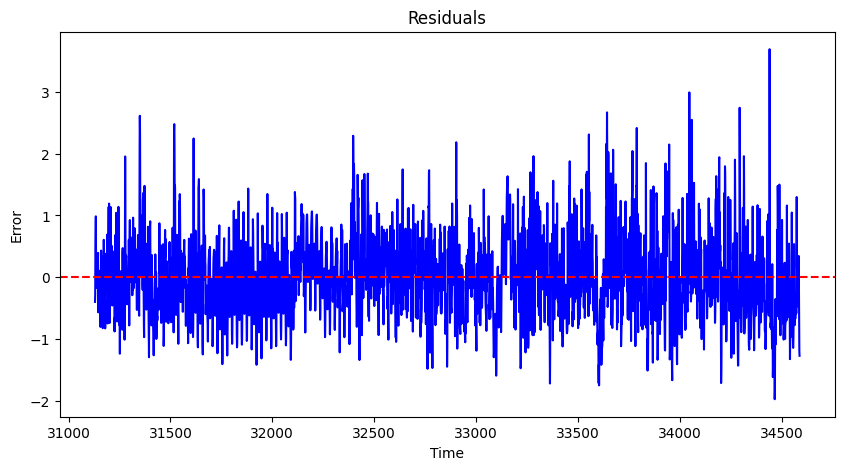

In [54]:
residuals = test['y'] - forecast_test['yhat']

plt.figure(figsize=(10,5))
plt.plot(residuals, color='blue')

plt.axhline(0, color='red', linestyle='--')

plt.title('Residuals')
plt.xlabel('Time')
plt.ylabel('Error')

plt.show()

### Residual Distribution

- This plot shows the distribution of prediction errors.
- A well-performing model should have residuals centered around zero.

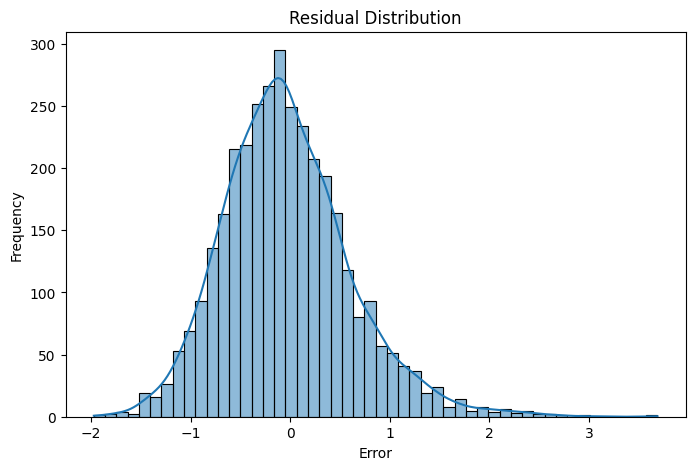

In [55]:
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=50, kde=True)

plt.title('Residual Distribution')
plt.xlabel('Error')
plt.ylabel('Frequency')

plt.show()

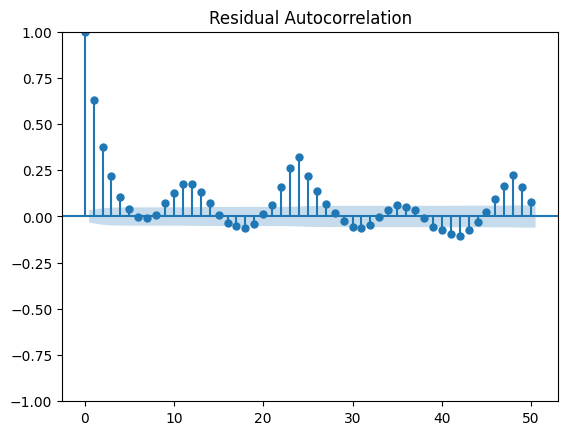

In [56]:
plot_acf(residuals, lags=50)
plt.title("Residual Autocorrelation")
plt.show()

### Residual Autocorrelation

- This checks whether residuals are independent.
- Ideally, no significant autocorrelation should be present.

### 16. Walk-Forward Validation

A simple walk-forward validation approach was implemented by training the model on historical data and forecasting the next 24 hours.

This helps evaluate how well the model generalizes to unseen future data.

In [57]:
train_small = prophet_df[:-24]
test_small = prophet_df[-24:]

model = Prophet(daily_seasonality=True, weekly_seasonality=True)
model.fit(train_small)

future = model.make_future_dataframe(periods=24, freq='h')
forecast = model.predict(future)

pred = forecast[['ds','yhat']].tail(24)

mae_wf = mean_absolute_error(test_small['y'], pred['yhat'])
print("Walk-forward MAE:", mae_wf)

11:38:24 - cmdstanpy - INFO - Chain [1] start processing
11:38:32 - cmdstanpy - INFO - Chain [1] done processing


Walk-forward MAE: 0.39589413103617854


The walk-forward validation MAE is lower than the test MAE, indicating that the model performs well in short-term forecasting scenarios.

This demonstrates strong generalization ability for near-future predictions.

In [58]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(24)

,ds,yhat,yhat_lower,yhat_upper
34565,2010-11-25 22:00:00,1.618100,0.706558,2.532188
34566,2010-11-25 23:00:00,1.191629,0.314866,2.190855
34567,2010-11-26 00:00:00,0.911721,-0.120128,1.809334
34568,2010-11-26 01:00:00,0.786547,-0.086719,1.663348
34569,2010-11-26 02:00:00,0.718905,-0.245635,1.692612
34570,2010-11-26 03:00:00,0.652592,-0.238190,1.529446
34571,2010-11-26 04:00:00,0.647675,-0.221109,1.551393
34572,2010-11-26 05:00:00,0.807853,-0.117807,1.764622
34573,2010-11-26 06:00:00,1.141420,0.207935,2.099764
34574,2010-11-26 07:00:00,1.508796,0.640970,2.419325


### 17. 24-Hour Forecast Output

In [59]:
future_24 = model.make_future_dataframe(periods=24, freq='h')
forecast_24 = model.predict(future_24)

forecast_24[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(24)

,ds,yhat,yhat_lower,yhat_upper
34565,2010-11-25 22:00:00,1.618100,0.687222,2.530057
34566,2010-11-25 23:00:00,1.191629,0.276563,2.114678
34567,2010-11-26 00:00:00,0.911721,-0.030115,1.839024
34568,2010-11-26 01:00:00,0.786547,-0.230189,1.663853
34569,2010-11-26 02:00:00,0.718905,-0.224114,1.634254
34570,2010-11-26 03:00:00,0.652592,-0.267225,1.643672
34571,2010-11-26 04:00:00,0.647675,-0.227058,1.594382
34572,2010-11-26 05:00:00,0.807853,-0.080552,1.726842
34573,2010-11-26 06:00:00,1.141420,0.211809,2.020661
34574,2010-11-26 07:00:00,1.508796,0.547580,2.464492


### 18. Key Observations

- Prophet effectively captures daily and weekly seasonality.
- The model provides uncertainty intervals, which are useful for decision-making.
- Forecasts align well with historical trends.